In [10]:
###Transformer训练AML风险化学物筛选

In [11]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (accuracy_score, roc_auc_score, 
                             confusion_matrix, classification_report)
import optuna
from optuna.trial import TrialState
import os
import warnings
import shap
import matplotlib.pyplot as plt

warnings.filterwarnings('ignore')

In [12]:
# ===================== 0. 设定随机种子以保证可重现性 =====================
import random
SEED = 3407  # 设置随机种子为3407

def set_seed(seed=SEED):
    """设置所有随机种子以保证可重现性"""
    random.seed(seed)  # Python随机种子
    np.random.seed(seed)  # NumPy随机种子
    torch.manual_seed(seed)  # PyTorch CPU随机种子
    
    # 设置CUDA随机种子（如果有GPU）
    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)
        torch.backends.cudnn.deterministic = True
        torch.backends.cudnn.benchmark = False
    
    # 设置Python哈希种子
    os.environ['PYTHONHASHSEED'] = str(seed)
    
    print(f"✅ 随机种子已设置为: {seed}")

# ===================== 1. 配置全局参数（CPU适配+低计算量） =====================
DEVICE = torch.device("cpu")  # 强制使用CPU
BATCH_SIZE_BASE = 8  # 小批次降低CPU负载
MAX_EPOCHS = 50      # 限制训练轮数
EARLY_STOPPING_PATIENCE = 8  # 早停减少无效训练
MAX_SEQ_LEN = 64     # SMILES最大长度（缩短序列降低计算量）
FEAT_DIM = 119       # 固定分子特征维度为119（无需自动推断）
MODEL_SAVE_DIR = "chem_models"  # 模型保存目录
os.makedirs(MODEL_SAVE_DIR, exist_ok=True)

# 全局变量：存储训练集类别权重（供Optuna调参使用）
POS_WEIGHT = None

In [13]:
# ===================== 2. 数据加载与预处理 =====================
class ChemDataset(Dataset):
    """化学物数据集类（适配SMILES+分子特征）"""
    def __init__(self, smiles, features, labels, smiles_vocab, scaler=None):
        self.smiles = smiles
        self.features = features
        self.labels = labels
        self.smiles_vocab = smiles_vocab
        self.scaler = scaler
        
        # 标准化分子特征（仅训练集拟合scaler）
        if self.scaler is not None:
            self.features = self.scaler.transform(self.features)
    
    def _smiles_to_seq(self, smiles):
        """SMILES字符串转数字序列（截断/填充）"""
        seq = [self.smiles_vocab.get(c, 1) for c in smiles[:MAX_SEQ_LEN]]  # 1=未知字符
        # 填充到MAX_SEQ_LEN
        if len(seq) < MAX_SEQ_LEN:
            seq += [0] * (MAX_SEQ_LEN - len(seq))  # 0=填充符
        return np.array(seq)
    
    def __len__(self):
        return len(self.labels)
    
    def __getitem__(self, idx):
        # SMILES序列（Long型）
        smiles_seq = torch.LongTensor(self._smiles_to_seq(self.smiles[idx]))
        # 分子特征（Float型）
        feat = torch.FloatTensor(self.features[idx])
        # 标签（Float型，二分类）
        label = torch.FloatTensor([self.labels[idx]])
        return smiles_seq, feat, label

def load_data(csv_path, target_col="Activity"):
    """加载CSV数据并预处理（核心：Activity标签二值化）"""
    # 读取数据（列：SMILES + 119项分子特征 + Activity）
    df = pd.read_csv(csv_path)
    
    # ========== 核心修改1：Activity标签二值化 ==========
    # Active → 1，Inactive → 0（忽略大小写）
    df[target_col] = df[target_col].str.strip().str.lower().map({
        "active": 1,
        "inactive": 0
    })
    # 处理异常值（若有非Active/Inactive的标签，直接删除）
    df = df.dropna(subset=[target_col])
    df[target_col] = df[target_col].astype(int)
    
    # 1. 提取SMILES并构建词汇表（低计算量：仅保留高频字符）
    smiles_col = "SMILES" if "SMILES" in df.columns else "smiles"  # 兼容大小写列名
    smiles_list = df[smiles_col].tolist()
    char_counts = {}
    for s in smiles_list:
        for c in s:
            char_counts[c] = char_counts.get(c, 0) + 1
    # 仅保留出现次数>5的字符，降低词汇表大小
    vocab = {c:i+2 for i, (c, cnt) in enumerate(char_counts.items()) if cnt>5}
    vocab["<PAD>"] = 0  # 填充符
    vocab["<UNK>"] = 1  # 未知字符
    
    # 2. 提取119项分子特征（排除SMILES和Activity列）
    feat_cols = [col for col in df.columns if col not in [smiles_col, target_col]]
    # 验证特征数量是否为119
    if len(feat_cols) != 119:
        raise ValueError(f"分子特征数量不为119！当前检测到{len(feat_cols)}项特征")
    # 缺失值填充0（化学特征常见处理方式）
    features = df[feat_cols].fillna(0).values

    # 3.提取标签并计算全局pos_weight（负类数/正类数）
    labels = df[target_col].values
    global POS_WEIGHT
    pos_num = np.sum(labels == 1)
    neg_num = np.sum(labels == 0)
    POS_WEIGHT = neg_num / pos_num if pos_num > 0 else 1.0
    print(f"类别权重pos_weight（负类数/正类数）: {POS_WEIGHT:.4f}")
    
    # 4. 提取二值化后的标签
    labels = df[target_col].values
    
    # 5. 划分训练集/验证集（7:3，分层抽样保证类别分布）
    train_smiles, val_smiles, train_feat, val_feat, train_label, val_label = train_test_split(
        smiles_list, features, labels, test_size=0.3, random_state=SEED, stratify=labels
    )
    
    # 6. 标准化分子特征（仅训练集拟合）
    scaler = StandardScaler()
    train_feat = scaler.fit_transform(train_feat)
    
    # 7.构建数据集
    train_dataset = ChemDataset(train_smiles, train_feat, train_label, vocab, scaler=None)
    val_dataset = ChemDataset(val_smiles, val_feat, val_label, vocab, scaler=scaler)
    
    # 8.构建DataLoader（小批次+num_workers=0适配CPU）
    train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE_BASE, shuffle=True, num_workers=0)
    val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE_BASE*2, shuffle=False, num_workers=0)
    
    # 返回特征列名
    return train_loader, val_loader, vocab, scaler, val_smiles, val_feat, val_label, feat_cols

In [14]:
# ===================== 3. 轻量级Transformer模型 =====================
class SimpleTransformerModel(nn.Module):
    """轻量级Transformer模型（适配CPU+低计算量）"""
    def __init__(self, vocab_size, d_model=64, nhead=2, num_layers=1, dropout=0.1):
        super().__init__()
        # 1. SMILES嵌入层
        self.smiles_emb = nn.Embedding(vocab_size, d_model, padding_idx=0)
        # 2. 位置编码（简化版：可学习位置编码）
        self.pos_emb = nn.Embedding(MAX_SEQ_LEN, d_model)
        # 3. 分子特征投影层（匹配d_model）
        self.feat_proj = nn.Linear(FEAT_DIM, d_model)
        # 4. 轻量级Transformer编码器
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model, 
            nhead=nhead,
            dim_feedforward=d_model*2,  # 降低FFN维度（默认4倍→2倍）
            dropout=dropout,
            activation="gelu",
            batch_first=True,  # 输入格式：[batch, seq_len, d_model]
            device=DEVICE
        )
        self.transformer_encoder = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)
        # 5. 分类头（低计算量：仅1层全连接）
        self.classifier = nn.Sequential(
            nn.Linear(d_model*2, d_model),  # 拼接SMILES特征+分子特征
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(d_model, 1),
        )
    
    def forward(self, smiles_seq, feat):
        # 1. SMILES嵌入 + 位置编码
        batch_size = smiles_seq.shape[0]
        pos = torch.arange(0, MAX_SEQ_LEN).unsqueeze(0).repeat(batch_size, 1).to(DEVICE)
        smiles_feat = self.smiles_emb(smiles_seq) + self.pos_emb(pos)
        
        # 2. Transformer编码（屏蔽padding位）
        padding_mask = (smiles_seq == 0)  # [batch, seq_len]
        enc_out = self.transformer_encoder(smiles_feat, src_key_padding_mask=padding_mask)
        # 取SMILES序列的平均池化（替代CLS token，降低计算量）
        smiles_pooled = enc_out.masked_fill(padding_mask.unsqueeze(-1), 0).sum(1) / (~padding_mask).sum(1).unsqueeze(-1)
        
        # 3. 分子特征投影
        feat_proj = self.feat_proj(feat)
        
        # 4. 拼接特征并分类
        concat_feat = torch.cat([smiles_pooled, feat_proj], dim=1)
        out = self.classifier(concat_feat)
        return out

In [15]:
# ===================== 4. 模型评价指标计算函数 =====================
def calculate_metrics(y_true, y_pred_prob, threshold=0.5):
    y_pred = (y_pred_prob >= threshold).astype(int)
    try:
        tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    except ValueError:
        tn = fp = fn = tp = 0
        if (y_true == 0).all():
            tn = len(y_true)
        elif (y_true == 1).all():
            tp = len(y_true)
    
    # 计算核心指标
    total = tp + tn + fp + fn
    metrics = {
        "accuracy": (tp + tn) / total if total > 0 else 0.0,
        "sensitivity": tp / (tp + fn) if (tp + fn) > 0 else 0.0,
        "specificity": tn / (tn + fp) if (tn + fp) > 0 else 0.0,
        "precision": tp / (tp + fp) if (tp + fp) > 0 else 0.0,
        "f1": 2 * tp / (2 * tp + fp + fn) if (2 * tp + fp + fn) > 0 else 0.0,
        "auc": roc_auc_score(y_true, y_pred_prob) if len(set(y_true)) > 1 else 0.5
    }
    return metrics


In [16]:
# ===================== 5. Optuna自动调参（核心修改：BCEWithLogitsLoss + pos_weight） =====================
def objective(trial: optuna.Trial):
    """Optuna目标函数：使用BCEWithLogitsLoss + pos_weight"""

    # 设置随机种子以保证每次试验可重现
    set_seed(SEED)
    
    # 待调超参数
    params = {
        "d_model": trial.suggest_categorical("d_model", [32, 64]),
        "nhead": trial.suggest_categorical("nhead", [2, 4]),
        "num_layers": trial.suggest_int("num_layers", 1, 2),
        "dropout": trial.suggest_float("dropout", 0.1, 0.2),
        "lr": trial.suggest_float("lr", 1e-4, 5e-4, log=True),
        "weight_decay": trial.suggest_float("weight_decay", 1e-5, 1e-4, log=True),
        "batch_size": trial.suggest_categorical("batch_size", [8, 16])
    }
    
    # 构建模型
    vocab_size = len(vocab)
    model = SimpleTransformerModel(
        vocab_size=vocab_size,
        d_model=params["d_model"],
        nhead=params["nhead"],
        num_layers=params["num_layers"],
        dropout=params["dropout"]
    ).to(DEVICE)
    
    # 核心修改：使用BCEWithLogitsLoss + pos_weight
    criterion = nn.BCEWithLogitsLoss(pos_weight=torch.tensor(POS_WEIGHT, device=DEVICE))
    optimizer = optim.AdamW(model.parameters(), lr=params["lr"], weight_decay=params["weight_decay"])
    
    # 训练初始化
    best_val_auc = 0.0
    patience_counter = 0
    best_model_state = None
    
    for epoch in range(MAX_EPOCHS):
        # 训练阶段
        model.train()
        train_loss = 0.0
        for batch in train_loader:
            smiles_seq, feat, label = [x.to(DEVICE) for x in batch]
            optimizer.zero_grad()
            logits = model(smiles_seq, feat)  # 输出Logits
            loss = criterion(logits, label)   # 直接传入Logits计算损失
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()
            train_loss += loss.item()
        
        # 验证阶段
        model.eval()
        val_loss = 0.0
        val_preds_prob = []  # 存储Sigmoid后的概率
        val_labels = []
        with torch.no_grad():
            for batch in val_loader:
                smiles_seq, feat, label = [x.to(DEVICE) for x in batch]
                logits = model(smiles_seq, feat)
                loss = criterion(logits, label)
                val_loss += loss.item()
                # 将Logits转为概率（Sigmoid）
                pred_prob = torch.sigmoid(logits).cpu().numpy().flatten()
                val_preds_prob.extend(pred_prob)
                val_labels.extend(label.cpu().numpy().flatten())
        
        # 计算验证集AUC
        val_auc = roc_auc_score(val_labels, val_preds_prob) if len(set(val_labels))>1 else 0.5
        
        # 早停判断
        if val_auc > best_val_auc:
            best_val_auc = val_auc
            patience_counter = 0
            best_model_state = model.state_dict().copy()
        else:
            patience_counter += 1
            if patience_counter >= EARLY_STOPPING_PATIENCE:
                break
        
        # 打印日志
        if epoch % 5 == 0:
            print(f"Trial {trial.number} | Epoch {epoch} | Train Loss: {train_loss/len(train_loader):.4f} | Val AUC: {val_auc:.4f}")
    
    # 保存最优模型
    if best_model_state is not None:
        model_path = os.path.join(MODEL_SAVE_DIR, f"best_model_trial_{trial.number}.pth")
        torch.save({
            "model_state_dict": best_model_state,
            "params": params,
            "val_auc": best_val_auc
        }, model_path)
        trial.set_user_attr("model_path", model_path)
    
    return best_val_auc

In [17]:
# ===================== 6. SHAP分析（修复维度问题） =====================
def shap_analysis(model, val_loader, scaler, feat_cols):
    """
    仅分析分子特征的SHAP值（避免SMILES序列维度干扰）
    """
    # 1. 提取验证集数据（仅保留分子特征，固定SMILES为验证集第一个样本的序列）
    val_feat_list = []
    val_label_list = []
    ref_smiles_seq = None  # 参考SMILES序列（固定）
    
    for batch in val_loader:
        smiles_seq, feat, label = batch
        # 取第一个batch的第一个样本作为参考SMILES序列（固定）
        if ref_smiles_seq is None:
            ref_smiles_seq = smiles_seq[0:1].to(DEVICE)  # [1, 64]
        val_feat_list.extend(feat.numpy())
        val_label_list.extend(label.numpy())
    
    val_feat = np.array(val_feat_list)  # [n_samples, 119]
    print(f"分子特征维度: {val_feat.shape}")
    print(f"参考SMILES序列维度: {ref_smiles_seq.shape}")
    
    # 2. 构建预测函数（仅输入分子特征，SMILES固定为参考序列）
    def predict_fn(feat_np):
        """
        输入：标准化分子特征 [n_samples, 119]
        输出：预测概率 [n_samples]
        """
        model.eval()
        preds = []
        with torch.no_grad():
            # 参考SMILES序列重复n_samples次，匹配分子特征的样本数
            batch_smiles = ref_smiles_seq.repeat(feat_np.shape[0], 1)  # [n_samples, 64]
            feat_tensor = torch.FloatTensor(feat_np).to(DEVICE)       # [n_samples, 119]
            
            logits = model(batch_smiles, feat_tensor)
            pred_prob = torch.sigmoid(logits).cpu().numpy().flatten()
            preds.extend(pred_prob)
        return np.array(preds)
    
    # 3. 初始化SHAP解释器（KernelExplainer，适配CPU）
    # 背景数据：随机采样10个验证集分子特征（维度匹配）
    background_size = min(10, len(val_feat))
    background_feat = val_feat[np.random.choice(len(val_feat), background_size, replace=False)]
    print(f"背景数据维度: {background_feat.shape}")
    
    explainer = shap.KernelExplainer(predict_fn, background_feat)
    
    # 4. 计算SHAP值（采样20个样本，控制计算量）
    sample_size = min(20, len(val_feat))
    sample_feat = val_feat[np.random.choice(len(val_feat), sample_size, replace=False)]
    print(f"分析样本维度: {sample_feat.shape}")
    
    # 关键：nsamples减小以适配CPU，避免内存溢出
    shap_values = explainer.shap_values(sample_feat, nsamples=20)
    
    # 5. 可视化（修复维度不匹配问题）
    plt.rcParams["font.size"] = 8
    plt.rcParams["figure.figsize"] = (12, 8)
    
    # 5.1 特征重要性条形图
    shap.summary_plot(shap_values, sample_feat, feature_names=feat_cols, plot_type="bar", show=False)
    plt.title("SHAP Feature Importance (Molecular Features)")
    plt.tight_layout()
    plt.savefig(os.path.join(MODEL_SAVE_DIR, "shap_bar.png"), dpi=150, bbox_inches="tight")
    plt.close()
    
    # 5.2 特征贡献散点图
    shap.summary_plot(shap_values, sample_feat, feature_names=feat_cols, show=False)
    plt.title("SHAP Feature Contribution (Molecular Features)")
    plt.tight_layout()
    plt.savefig(os.path.join(MODEL_SAVE_DIR, "shap_summary.png"), dpi=150, bbox_inches="tight")
    plt.close()
    
    # 5.3 Top3特征的依赖图
    shap_sum = np.abs(shap_values).mean(axis=0)
    top3_idx = np.argsort(shap_sum)[-3:]
    for idx in top3_idx:
        feat_name = feat_cols[idx]
        shap.dependence_plot(
            idx, shap_values, sample_feat, feature_names=feat_cols,
            show=False, x_jitter=0.1
        )
        plt.title(f"SHAP Dependence: {feat_name}")
        plt.tight_layout()
        plt.savefig(os.path.join(MODEL_SAVE_DIR, f"shap_dep_{feat_name}.png"), dpi=150, bbox_inches="tight")
        plt.close()
    
    print(f"\nSHAP分析完成！结果保存至 {MODEL_SAVE_DIR}")
    return shap_values

In [18]:
# ===================== 6. 主函数 =====================
if __name__ == "__main__":
    # 0. 设置随机种子以保证可重现性
    set_seed(SEED)
    
    # 1. 加载数据（替换为你的CSV路径）
    CSV_PATH = "C:\\Users\\HONOR\\molecular_descriptorsAML9.6.csv"
    try:
        train_loader, val_loader, vocab, scaler, val_smiles, val_feat, val_label, feat_cols = load_data(CSV_PATH)
    except (ValueError, FileNotFoundError) as e:
        print(f"数据加载错误：{e}")
        exit(1)
    
    # 2. Optuna调参 - 设置采样器的随机种子
    study = optuna.create_study(
        direction="maximize", 
        study_name="chem_toxicity_transformer",
        sampler=optuna.samplers.TPESampler(seed=SEED)  # 设置采样器随机种子
    )
    study.optimize(objective, n_trials=6, timeout=3600)
    
    # 3. 输出调参结果
    pruned_trials = study.get_trials(deepcopy=False, states=[TrialState.PRUNED])
    complete_trials = study.get_trials(deepcopy=False, states=[TrialState.COMPLETE])
    print("\n===== 调参结果汇总 =====")
    print(f"试验总数: {len(study.trials)}")
    print(f"剪枝试验数: {len(pruned_trials)}")
    print(f"完成试验数: {len(complete_trials)}")
    
    if not study.best_trial:
        print("无有效试验结果！")
        exit(1)
    
    print(f"最优参数: {study.best_params}")
    print(f"最优验证集AUC（调参阶段）: {study.best_value:.4f}")
    
    # 4. 加载最优模型并计算指标
    print("\n===== 最优模型完整评价指标 =====")
    best_trial = study.best_trial
    model_path = best_trial.user_attrs.get("model_path")
    
    # 模型加载逻辑
    if not model_path or not os.path.exists(model_path):
        print("警告：最优模型文件不存在，重新训练最优参数模型...")
        best_model = SimpleTransformerModel(
            vocab_size=len(vocab),
            d_model=best_trial.params["d_model"],
            nhead=best_trial.params["nhead"],
            num_layers=best_trial.params["num_layers"],
            dropout=best_trial.params["dropout"]
        ).to(DEVICE)
        # 重新训练少量轮数
        optimizer = optim.AdamW(best_model.parameters(), 
                               lr=best_trial.params["lr"], 
                               weight_decay=best_trial.params["weight_decay"])
        criterion = nn.BCEWithLogitsLoss(pos_weight=torch.tensor(POS_WEIGHT, device=DEVICE))
        best_model.train()
        for _ in range(6):
            for batch in train_loader:
                smiles_seq, feat, label = [x.to(DEVICE) for x in batch]
                optimizer.zero_grad()
                logits = best_model(smiles_seq, feat)
                loss = criterion(logits, label)
                loss.backward()
                optimizer.step()
    else:
        checkpoint = torch.load(model_path, map_location=DEVICE)
        if "model_state_dict" not in checkpoint:
            raise KeyError("模型文件中缺少 'model_state_dict' 键！")
        best_model = SimpleTransformerModel(
            vocab_size=len(vocab),
            d_model=best_trial.params["d_model"],
            nhead=best_trial.params["nhead"],
            num_layers=best_trial.params["num_layers"],
            dropout=best_trial.params["dropout"]
        ).to(DEVICE)
        best_model.load_state_dict(checkpoint["model_state_dict"])
    
    # 生成验证集预测结果
    best_model.eval()
    final_val_preds_prob = []
    final_val_labels = []
    with torch.no_grad():
        for batch in val_loader:
            smiles_seq, feat, label = [x.to(DEVICE) for x in batch]
            logits = best_model(smiles_seq, feat)
            pred_prob = torch.sigmoid(logits).cpu().numpy().flatten()
            final_val_preds_prob.extend(pred_prob)
            final_val_labels.extend(label.cpu().numpy().flatten())
    
    # 计算并输出指标
    metrics = calculate_metrics(np.array(final_val_labels), np.array(final_val_preds_prob))
    print(f"准确率 (Accuracy): {metrics['accuracy']:.4f}")
    print(f"灵敏度 (Sensitivity) → 检测Active的能力: {metrics['sensitivity']:.4f}")
    print(f"特异性 (Specificity) → 检测Inactive的能力: {metrics['specificity']:.4f}")
    print(f"精确率 (Precision): {metrics['precision']:.4f}")
    print(f"F1 分数 (F1-Score): {metrics['f1']:.4f}")
    print(f"AUC: {metrics['auc']:.4f}")
    
    # 详细分类报告
    print("\n===== 详细分类报告 =====")
    target_names = ["Inactive (0)", "Active (1)"]
    try:
        print(classification_report(
            final_val_labels, 
            (np.array(final_val_preds_prob)>=0.5).astype(int), 
            target_names=target_names,
            digits=4
        ))
    except:
        print("分类报告生成失败（可能仅单类别）")

    # 执行SHAP分析（核心修复）
    shap_analysis(best_model, val_loader, scaler, feat_cols)
     
    print("\n最优模型加载并完成指标计算！")

    
    # ===================== 7. 保存最佳模型 =====================
    print("\n===== 保存最佳模型 =====")
    
    # 创建最佳模型保存路径
    BEST_MODEL_PATH = os.path.join(MODEL_SAVE_DIR, "best_transformer_model.pth")
    
    # 准备要保存的所有信息
    model_save_data = {
        # 1. 模型参数
        "model_state_dict": best_model.state_dict(),
        "best_params": study.best_params,
        
        # 2. 数据信息
        "vocab": vocab,           # SMILES词汇表
        "feat_cols": feat_cols,   # 特征列名
        "scaler": scaler,         # 标准化器
        
        # 3. 模型架构信息
        "model_config": {
            "vocab_size": len(vocab),
            "d_model": best_trial.params["d_model"],
            "nhead": best_trial.params["nhead"],
            "num_layers": best_trial.params["num_layers"],
            "dropout": best_trial.params["dropout"],
            "max_seq_len": MAX_SEQ_LEN,
            "feat_dim": FEAT_DIM
        },
        
        # 4. 训练信息
        "training_info": {
            "pos_weight": POS_WEIGHT,
            "best_val_auc": study.best_value,
            "final_metrics": metrics,
            "device": str(DEVICE),
            "save_timestamp": pd.Timestamp.now().strftime("%Y-%m-%d %H:%M:%S")
        }
    }
    
    # 保存模型
    torch.save(model_save_data, BEST_MODEL_PATH)
    print(f"✅ 最佳模型已保存到: {BEST_MODEL_PATH}")
    print(f"   文件大小: {os.path.getsize(BEST_MODEL_PATH) / 1024:.2f} KB")
    
    # ===================== 8. 保存模型元数据（可读性更好）=====================
    metadata_path = os.path.join(MODEL_SAVE_DIR, "model_metadata.txt")
    with open(metadata_path, 'w', encoding='utf-8') as f:
        f.write("=" * 60 + "\n")
        f.write("Transformer AML风险化学物筛选模型 - 元数据\n")
        f.write("=" * 60 + "\n\n")
        
        f.write("1. 最佳参数\n")
        f.write("-" * 30 + "\n")
        for key, value in study.best_params.items():
            f.write(f"   {key}: {value}\n")
        
        f.write(f"\n2. 性能指标\n")
        f.write("-" * 30 + "\n")
        for key, value in metrics.items():
            f.write(f"   {key}: {value:.4f}\n")
        
        f.write(f"\n3. 数据信息\n")
        f.write("-" * 30 + "\n")
        f.write(f"   词汇表大小: {len(vocab)}\n")
        f.write(f"   特征数量: {len(feat_cols)}\n")
        f.write(f"   正负样本比例: 1:{POS_WEIGHT:.2f}\n")
        
        f.write(f"\n4. 模型架构\n")
        f.write("-" * 30 + "\n")
        for key, value in model_save_data["model_config"].items():
            f.write(f"   {key}: {value}\n")
        
        f.write(f"\n5. 文件信息\n")
        f.write("-" * 30 + "\n")
        f.write(f"   主模型文件: {BEST_MODEL_PATH}\n")
        f.write(f"   SHAP可视化: {MODEL_SAVE_DIR}/shap_*.png\n")
        f.write(f"   保存时间: {model_save_data['training_info']['save_timestamp']}\n")
    
    print(f"✅ 模型元数据已保存到: {metadata_path}")
    


[I 2025-12-20 19:10:17,535] A new study created in memory with name: chem_toxicity_transformer


✅ 随机种子已设置为: 3407
类别权重pos_weight（负类数/正类数）: 2.8421
✅ 随机种子已设置为: 3407
Trial 0 | Epoch 0 | Train Loss: 0.9592 | Val AUC: 0.6450
Trial 0 | Epoch 5 | Train Loss: 0.7036 | Val AUC: 0.7513
Trial 0 | Epoch 10 | Train Loss: 0.4085 | Val AUC: 0.8454
Trial 0 | Epoch 15 | Train Loss: 0.2321 | Val AUC: 0.8346
Trial 0 | Epoch 20 | Train Loss: 0.1512 | Val AUC: 0.8693


[I 2025-12-20 19:10:56,729] Trial 0 finished with value: 0.8771929824561404 and parameters: {'d_model': 64, 'nhead': 4, 'num_layers': 2, 'dropout': 0.1853698155178157, 'lr': 0.00030268355570024763, 'weight_decay': 9.24235826795539e-05, 'batch_size': 16}. Best is trial 0 with value: 0.8771929824561404.


✅ 随机种子已设置为: 3407
Trial 1 | Epoch 0 | Train Loss: 0.9809 | Val AUC: 0.6375
Trial 1 | Epoch 5 | Train Loss: 0.7895 | Val AUC: 0.6678
Trial 1 | Epoch 10 | Train Loss: 0.6802 | Val AUC: 0.7393
Trial 1 | Epoch 15 | Train Loss: 0.5174 | Val AUC: 0.8204
Trial 1 | Epoch 20 | Train Loss: 0.3555 | Val AUC: 0.8537
Trial 1 | Epoch 25 | Train Loss: 0.2859 | Val AUC: 0.8654
Trial 1 | Epoch 30 | Train Loss: 0.1767 | Val AUC: 0.8640


[I 2025-12-20 19:11:21,536] Trial 1 finished with value: 0.8675438596491228 and parameters: {'d_model': 32, 'nhead': 4, 'num_layers': 1, 'dropout': 0.16956514659802213, 'lr': 0.00033392252599341387, 'weight_decay': 1.7103006284662822e-05, 'batch_size': 8}. Best is trial 0 with value: 0.8771929824561404.


...

✅ 随机种子已设置为: 3407
Trial 5 | Epoch 0 | Train Loss: 0.9979 | Val AUC: 0.6443
Trial 5 | Epoch 5 | Train Loss: 0.8197 | Val AUC: 0.6421
Trial 5 | Epoch 10 | Train Loss: 0.7607 | Val AUC: 0.6662
Trial 5 | Epoch 15 | Train Loss: 0.6970 | Val AUC: 0.7197
Trial 5 | Epoch 20 | Train Loss: 0.6138 | Val AUC: 0.7693
Trial 5 | Epoch 25 | Train Loss: 0.5601 | Val AUC: 0.8004
Trial 5 | Epoch 30 | Train Loss: 0.4948 | Val AUC: 0.8132
Trial 5 | Epoch 35 | Train Loss: 0.4316 | Val AUC: 0.8184
Trial 5 | Epoch 40 | Train Loss: 0.3687 | Val AUC: 0.8246
Trial 5 | Epoch 45 | Train Loss: 0.3024 | Val AUC: 0.8289


[I 2025-12-20 19:13:22,144] Trial 5 finished with value: 0.8342105263157895 and parameters: {'d_model': 32, 'nhead': 2, 'num_layers': 1, 'dropout': 0.17889876572231503, 'lr': 0.00019327623529487038, 'weight_decay': 9.143114520025115e-05, 'batch_size': 8}. Best is trial 0 with value: 0.8771929824561404.



===== 调参结果汇总 =====
试验总数: 6
剪枝试验数: 0
完成试验数: 6
最优参数: {'d_model': 64, 'nhead': 4, 'num_layers': 2, 'dropout': 0.1853698155178157, 'lr': 0.00030268355570024763, 'weight_decay': 9.24235826795539e-05, 'batch_size': 16}
最优验证集AUC（调参阶段）: 0.8772

===== 最优模型完整评价指标 =====
准确率 (Accuracy): 0.8766
灵敏度 (Sensitivity) → 检测Active的能力: 0.6750
特异性 (Specificity) → 检测Inactive的能力: 0.9474
精确率 (Precision): 0.8182
F1 分数 (F1-Score): 0.7397
AUC: 0.8667

===== 详细分类报告 =====
              precision    recall  f1-score   support

Inactive (0)     0.8926    0.9474    0.9191       114
  Active (1)     0.8182    0.6750    0.7397        40

    accuracy                         0.8766       154
   macro avg     0.8554    0.8112    0.8294       154
weighted avg     0.8732    0.8766    0.8725       154

分子特征维度: (154, 119)
参考SMILES序列维度: torch.Size([1, 64])
背景数据维度: (10, 119)
分析样本维度: (20, 119)


  0%|          | 0/20 [00:00<?, ?it/s]


SHAP分析完成！结果保存至 chem_models

最优模型加载并完成指标计算！

===== 保存最佳模型 =====
✅ 最佳模型已保存到: chem_models\best_transformer_model.pth
   文件大小: 369.08 KB
✅ 模型元数据已保存到: chem_models\model_metadata.txt


加载已保存模型并绘制ROC曲线
✅ 模型加载成功: chem_models/best_transformer_model.pth

📋 模型元数据:
------------------------------
最佳参数:
  d_model: 64
  nhead: 4
  num_layers: 2
  dropout: 0.1853698155178157
  lr: 0.00030268355570024763
  weight_decay: 9.24235826795539e-05
  batch_size: 16

训练信息:
  最佳验证集AUC: 0.8772
  类别权重: 2.8421
  保存时间: 2025-12-20 19:13:29

最终性能指标:
  accuracy: 0.8766
  sensitivity: 0.6750
  specificity: 0.9474
  precision: 0.8182
  f1: 0.7397
  auc: 0.8667

📊 加载数据: C:\Users\HONOR\molecular_descriptorsAML9.6.csv
类别权重pos_weight（负类数/正类数）: 2.8421
✅ 数据加载成功
   验证集样本数: 154
   正样本(Active): 40
   负样本(Inactive): 114

🔧 重建模型架构...
✅ 模型重建成功
   模型架构: d_model=64, nhead=4, layers=2

📈 生成预测结果...
✅ 预测完成
   样本数量: 154
   预测概率范围: [0.0004, 1.0000]

📊 计算ROC曲线数据...
✅ ROC曲线计算完成
   AUC值: 0.8667
   最佳阈值: 0.0919
   对应灵敏度: 0.7000
   对应特异度: 0.9474

🎨 绘制ROC曲线...


ValueError: Each row in 'cellText' must have 3 columns

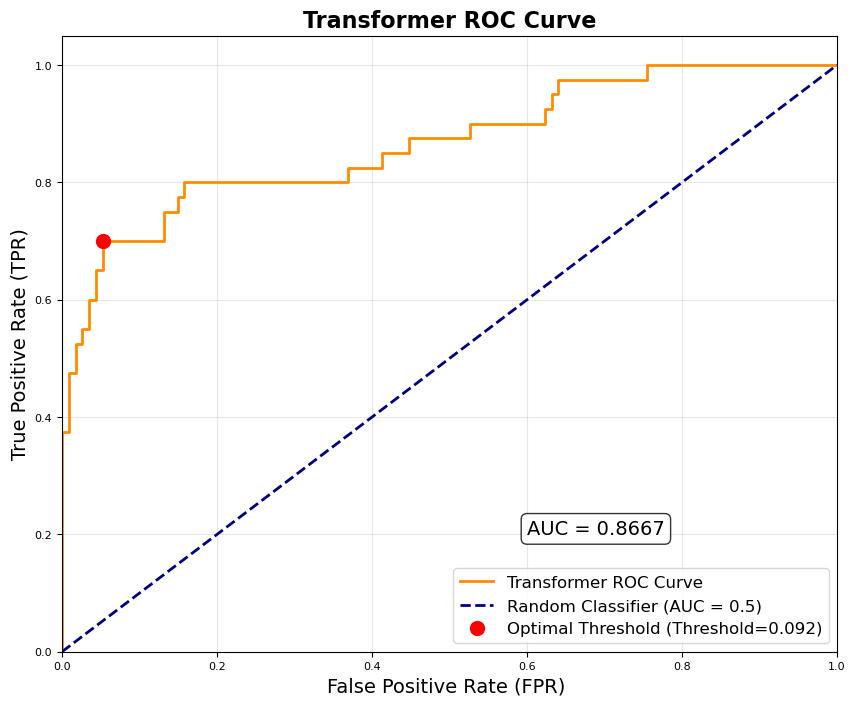

In [21]:
###绘制ROC曲线
# ===================== 9. 加载已保存模型并绘制ROC曲线 =====================

def load_and_plot_roc(model_path="chem_models/best_transformer_model.pth", 
                     csv_path="C:\\Users\\HONOR\\molecular_descriptorsAML9.6.csv"):
    """
    加载已保存的模型并绘制ROC曲线
    参数：
        model_path: 模型文件路径
        csv_path: 数据文件路径
    """
    
    print("=" * 60)
    print("加载已保存模型并绘制ROC曲线")
    print("=" * 60)
    
    # 1. 加载模型和元数据
    if not os.path.exists(model_path):
        print(f"❌ 模型文件不存在: {model_path}")
        return
    
    try:
        # 加载模型文件
        checkpoint = torch.load(model_path, map_location=DEVICE)
        print(f"✅ 模型加载成功: {model_path}")
        
        # 显示模型元数据
        print("\n📋 模型元数据:")
        print("-" * 30)
        
        # 打印最佳参数
        if "best_params" in checkpoint:
            print("最佳参数:")
            for key, value in checkpoint["best_params"].items():
                print(f"  {key}: {value}")
        
        # 打印训练信息
        if "training_info" in checkpoint:
            info = checkpoint["training_info"]
            print(f"\n训练信息:")
            print(f"  最佳验证集AUC: {info.get('best_val_auc', 'N/A'):.4f}")
            print(f"  类别权重: {info.get('pos_weight', 'N/A'):.4f}")
            print(f"  保存时间: {info.get('save_timestamp', 'N/A')}")
            
            # 打印最终指标
            if "final_metrics" in info:
                print(f"\n最终性能指标:")
                metrics = info["final_metrics"]
                for key, value in metrics.items():
                    print(f"  {key}: {value:.4f}")
    
    except Exception as e:
        print(f"❌ 加载模型失败: {e}")
        return
    
    # 2. 加载数据
    print(f"\n📊 加载数据: {csv_path}")
    try:
        # 使用之前定义的load_data函数
        train_loader, val_loader, vocab, scaler, val_smiles, val_feat, val_label, feat_cols = load_data(csv_path)
        print(f"✅ 数据加载成功")
        print(f"   验证集样本数: {len(val_label)}")
        print(f"   正样本(Active): {np.sum(val_label == 1)}")
        print(f"   负样本(Inactive): {np.sum(val_label == 0)}")
    except Exception as e:
        print(f"❌ 数据加载失败: {e}")
        return
    
    # 3. 重建模型
    print("\n🔧 重建模型架构...")
    try:
        model_config = checkpoint["model_config"]
        vocab = checkpoint["vocab"]
        feat_cols = checkpoint["feat_cols"]
        
        # 重建模型
        model = SimpleTransformerModel(
            vocab_size=model_config["vocab_size"],
            d_model=model_config["d_model"],
            nhead=model_config["nhead"],
            num_layers=model_config["num_layers"],
            dropout=model_config["dropout"]
        ).to(DEVICE)
        
        # 加载权重
        model.load_state_dict(checkpoint["model_state_dict"])
        model.eval()
        print("✅ 模型重建成功")
        print(f"   模型架构: d_model={model_config['d_model']}, "
              f"nhead={model_config['nhead']}, "
              f"layers={model_config['num_layers']}")
        
    except Exception as e:
        print(f"❌ 模型重建失败: {e}")
        return
    
    # 4. 在验证集上生成预测
    print("\n📈 生成预测结果...")
    y_true = []
    y_pred_proba = []
    
    with torch.no_grad():
        for batch in val_loader:
            smiles_seq, feat, label = [x.to(DEVICE) for x in batch]
            logits = model(smiles_seq, feat)
            pred_prob = torch.sigmoid(logits).cpu().numpy().flatten()
            y_pred_proba.extend(pred_prob)
            y_true.extend(label.cpu().numpy().flatten())
    
    y_true = np.array(y_true)
    y_pred_proba = np.array(y_pred_proba)
    
    print(f"✅ 预测完成")
    print(f"   样本数量: {len(y_true)}")
    print(f"   预测概率范围: [{y_pred_proba.min():.4f}, {y_pred_proba.max():.4f}]")
    
    # 5. 计算ROC曲线数据
    print("\n📊 计算ROC曲线数据...")
    from sklearn.metrics import roc_curve, auc, roc_auc_score
    
    # 计算ROC曲线
    fpr, tpr, thresholds = roc_curve(y_true, y_pred_proba)
    roc_auc = roc_auc_score(y_true, y_pred_proba)
    
    # 计算最佳阈值（Youden's J统计量）
    j_scores = tpr - fpr
    optimal_idx = np.argmax(j_scores)
    optimal_threshold = thresholds[optimal_idx]
    
    print(f"✅ ROC曲线计算完成")
    print(f"   AUC值: {roc_auc:.4f}")
    print(f"   最佳阈值: {optimal_threshold:.4f}")
    print(f"   对应灵敏度: {tpr[optimal_idx]:.4f}")
    print(f"   对应特异度: {1 - fpr[optimal_idx]:.4f}")
    
    # 6. 绘制ROC曲线
    print("\n🎨 绘制ROC曲线...")
    plt.figure(figsize=(10, 8))
    
    # 绘制ROC曲线
    plt.plot(fpr, tpr, color='darkorange', lw=2, 
             label=f'Transformer ROC Curve')
    
    # 绘制对角线（随机猜测）
    plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', 
             label='Random Classifier (AUC = 0.5)')
    
    # 标记最佳阈值点
    plt.plot(fpr[optimal_idx], tpr[optimal_idx], 'ro', markersize=10, 
             label=f'Optimal Threshold (Threshold={optimal_threshold:.3f})')
    
    # 设置图形属性
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate (FPR) ', fontsize=14)
    plt.ylabel('True Positive Rate (TPR)', fontsize=14)
    plt.title('Transformer ROC Curve', fontsize=16, fontweight='bold')
    plt.legend(loc="lower right", fontsize=12)
    plt.grid(True, alpha=0.3)
    
    # 添加AUC文本
    plt.text(0.6, 0.2, f'AUC = {roc_auc:.4f}', fontsize=14,
             bbox=dict(boxstyle="round,pad=0.3", facecolor="white", alpha=0.8))
    
    # 添加阈值信息表格
    col_labels = ['指标', '值']
    table_data = ['AUC', f'{roc_auc:.4f}']
    
    table = plt.table(cellText=table_data, 
                      colLabels=col_labels,
                      colWidths=[0.15, 0.15],
                      cellLoc='center',
                      loc='lower left',
                      bbox=[0.02, 0.6, 0.2, 0.25])
    
    table.auto_set_font_size(False)
    table.set_fontsize(11)
    table.scale(1, 1.5)
    
    # 保存图像
    roc_save_path = os.path.join(MODEL_SAVE_DIR, "roc_curve.png")
    plt.tight_layout()
    plt.savefig(roc_save_path, dpi=300, bbox_inches='tight')
    plt.show()
    
    print(f"✅ ROC曲线已保存至: {roc_save_path}")
    
    # 7. 绘制预测概率分布图
    print("\n📊 绘制预测概率分布...")
    plt.figure(figsize=(12, 5))
    
    # 按真实类别分组
    active_probs = y_pred_proba[y_true == 1]
    inactive_probs = y_pred_proba[y_true == 0]
    
    # 创建子图
    plt.subplot(1, 2, 1)
    plt.hist(active_probs, bins=20, alpha=0.7, color='red', label='Active (真实正例)')
    plt.hist(inactive_probs, bins=20, alpha=0.7, color='blue', label='Inactive (真实负例)')
    plt.xlabel('预测概率', fontsize=12)
    plt.ylabel('样本数量', fontsize=12)
    plt.title('预测概率分布', fontsize=14)
    plt.legend()
    plt.grid(True, alpha=0.3)
    
    # 添加垂直最佳阈值线
    plt.axvline(x=optimal_threshold, color='green', linestyle='--', 
                linewidth=2, label=f'最佳阈值={optimal_threshold:.3f}')
    plt.legend()
    
    # 绘制类别分离箱线图
    plt.subplot(1, 2, 2)
    box_data = [inactive_probs, active_probs]
    box_labels = ['Inactive (0)', 'Active (1)']
    box_plot = plt.boxplot(box_data, labels=box_labels, patch_artist=True)
    
    # 设置箱线图颜色
    colors = ['lightblue', 'lightcoral']
    for patch, color in zip(box_plot['boxes'], colors):
        patch.set_facecolor(color)
    
    plt.xlabel('真实类别', fontsize=12)
    plt.ylabel('预测概率', fontsize=12)
    plt.title('各类别预测概率分布', fontsize=14)
    plt.grid(True, alpha=0.3, axis='y')
    
    plt.tight_layout()
    prob_dist_save_path = os.path.join(MODEL_SAVE_DIR, "probability_distribution.png")
    plt.savefig(prob_dist_save_path, dpi=300, bbox_inches='tight')
    plt.show()
    
    print(f"✅ 预测概率分布图已保存至: {prob_dist_save_path}")
    
    # 8. 打印详细性能报告
    print("\n" + "=" * 60)
    print("详细性能报告")
    print("=" * 60)
    
    # 使用最佳阈值生成预测标签
    y_pred = (y_pred_proba >= optimal_threshold).astype(int)
    
    # 计算混淆矩阵
    from sklearn.metrics import confusion_matrix, classification_report
    
    cm = confusion_matrix(y_true, y_pred)
    tn, fp, fn, tp = cm.ravel()
    
    print(f"\n混淆矩阵:")
    print(f"                 预测负例     预测正例")
    print(f"真实负例 (0)       {tn:4d} (TN)      {fp:4d} (FP)")
    print(f"真实正例 (1)       {fn:4d} (FN)      {tp:4d} (TP)")
    
    print(f"\n详细指标:")
    print(f"  准确率 (Accuracy): {(tp+tn)/(tp+tn+fp+fn):.4f}")
    print(f"  灵敏度 (Sensitivity/Recall): {tp/(tp+fn):.4f}")
    print(f"  特异度 (Specificity): {tn/(tn+fp):.4f}")
    print(f"  精确率 (Precision): {tp/(tp+fp):.4f}")
    print(f"  F1分数: {2*tp/(2*tp+fp+fn):.4f}")
    print(f"  AUC: {roc_auc:.4f}")
    
    print(f"\n分类报告:")
    print(classification_report(y_true, y_pred, target_names=['Inactive', 'Active'], digits=4))
    
    # 9. 保存详细性能报告到文件
    report_path = os.path.join(MODEL_SAVE_DIR, "performance_report.txt")
    with open(report_path, 'w', encoding='utf-8') as f:
        f.write("=" * 60 + "\n")
        f.write("Transformer AML风险化学物筛选模型 - 性能报告\n")
        f.write("=" * 60 + "\n\n")
        
        f.write("1. ROC曲线分析\n")
        f.write("-" * 40 + "\n")
        f.write(f"AUC: {roc_auc:.4f}\n")
        f.write(f"最佳阈值: {optimal_threshold:.4f}\n")
        f.write(f"对应灵敏度: {tpr[optimal_idx]:.4f}\n")
        f.write(f"对应特异度: {1 - fpr[optimal_idx]:.4f}\n\n")
        
        f.write("2. 混淆矩阵\n")
        f.write("-" * 40 + "\n")
        f.write(f"                预测负例     预测正例\n")
        f.write(f"真实负例 (0)       {tn:4d} (TN)      {fp:4d} (FP)\n")
        f.write(f"真实正例 (1)       {fn:4d} (FN)      {tp:4d} (TP)\n\n")
        
        f.write("3. 性能指标\n")
        f.write("-" * 40 + "\n")
        f.write(f"准确率 (Accuracy):           {(tp+tn)/(tp+tn+fp+fn):.4f}\n")
        f.write(f"灵敏度 (Sensitivity/Recall): {tp/(tp+fn):.4f}\n")
        f.write(f"特异度 (Specificity):        {tn/(tn+fp):.4f}\n")
        f.write(f"精确率 (Precision):          {tp/(tp+fp):.4f}\n")
        f.write(f"F1分数:                     {2*tp/(2*tp+fp+fn):.4f}\n")
        f.write(f"AUC:                        {roc_auc:.4f}\n\n")
        
        f.write("4. 数据统计\n")
        f.write("-" * 40 + "\n")
        f.write(f"验证集总样本数: {len(y_true)}\n")
        f.write(f"Active样本数: {np.sum(y_true == 1)}\n")
        f.write(f"Inactive样本数: {np.sum(y_true == 0)}\n")
        f.write(f"正负样本比例: 1:{np.sum(y_true == 0)/np.sum(y_true == 1):.2f}\n")
        
    print(f"\n📋 详细性能报告已保存至: {report_path}")
    
    print("\n" + "=" * 60)
    print("ROC曲线生成完成！")
    print(f"📁 所有结果保存至目录: {MODEL_SAVE_DIR}")
    print("=" * 60)


# 调用函数生成ROC曲线
if __name__ == "__main__":
    # 设置模型路径和数据路径
    MODEL_PATH = "chem_models/best_transformer_model.pth"
    DATA_PATH = "C:\\Users\\HONOR\\molecular_descriptorsAML9.6.csv"
    
    # 确保模型保存目录存在
    os.makedirs(MODEL_SAVE_DIR, exist_ok=True)
    
    # 加载模型并绘制ROC曲线
    load_and_plot_roc(MODEL_PATH, DATA_PATH)
